## Project Description
The purpose of this project is to develop neural networks that can identify metastatic cancer in small images taken from larger pathology scans.

github link: https://github.com/lsiver/ml3_week3

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from PIL import Image as PILImage
from IPython.display import display
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Cropping2D, CenterCrop
from keras import layers
from keras import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

## Data
Below I'm importing the data. There is a test set of images, a training set of images, and a csv file which lists the training images file name and its associated label (1/0) for whether metastatic cancer was present. The images are each 96 x 96 pixels, and according to kaggle, the label is only **1** if the center 32 x 32 pixel region of the image contains at least one pixel of tumor tissue. 

#### Data Size
The training set of images is ~**5.7gb** in size. 220,025 images, each 96 x 96 pixels and 3 layers (RGB).

The test set of images is ~**1.5gb** in size. 57,458 images, each 96 x 96 pixels and 3 layers (RGB).

As described on the Kaggle page for this dataset, this version has any duplicate images *removed* already. Checking for duplicates is not necessary, at least.

#### Data Transformation
It may improve the results to remove any parts of the image outside of the 32 x 32 pixel area. Runs with and without performing this will be attempted and see if there's any large difference in accuracy.

In [2]:
train_img_path = 'data/train/'
train_imgs = os.listdir(train_img_path)
test_img_path = 'data/test/'
test_imgs = os.listdir(test_img_path)
####
df = pd.read_csv('data/train_labels.csv')
df['id'] = df['id'].astype(str) + '.tif'
df['label'] = df['label'].astype(str)

In [3]:
test_img_dir = 'data/test'
test_img_list = os.listdir(test_img_dir)
test_img_list = [f for f in test_img_list if f.endswith('.tif')]
test_df = pd.DataFrame({'id':test_img_list})

In [4]:
df.head

<bound method NDFrame.head of                                                   id label
0       f38a6374c348f90b587e046aac6079959adf3835.tif     0
1       c18f2d887b7ae4f6742ee445113fa1aef383ed77.tif     1
2       755db6279dae599ebb4d39a9123cce439965282d.tif     0
3       bc3f0c64fb968ff4a8bd33af6971ecae77c75e08.tif     0
4       068aba587a4950175d04c680d38943fd488d6a9d.tif     0
...                                              ...   ...
220020  53e9aa9d46e720bf3c6a7528d1fca3ba6e2e49f6.tif     0
220021  d4b854fe38b07fe2831ad73892b3cec877689576.tif     1
220022  3d046cead1a2a5cbe00b2b4847cfb7ba7cf5fe75.tif     0
220023  f129691c13433f66e1e0671ff1fe80944816f5a2.tif     0
220024  a81f84895ddcd522302ddf34be02eb1b3e5af1cb.tif     1

[220025 rows x 2 columns]>

<hr>
The value counts of the cancerous (1) vs the benign (0) in the training set is shown below. This is not a severe imbalance and it should be OK as-is.

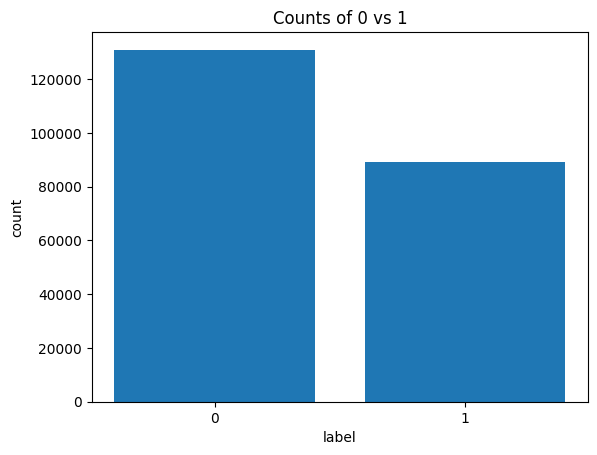

In [5]:
counts_01 = df['label'].value_counts()
plt.bar(counts_01.index,counts_01.values)
plt.xlabel('label')
plt.ylabel('count')
plt.title('Counts of 0 vs 1')
plt.show()

#### Overexposed / Outlier Images

A few of the images are "overexposed" and are mostly white-space. These will not add much value to the training. I will drop these from the training set. This is done by converting each image into a numpy array of (height,width,3) where each entry is a pixel intensity from 0-255. The mean is then calculated and this is stored in a list. 

Then, any images with a brightness intensity < 10 or > 245 is dropped from the dataframe `df` and will not be used in training.

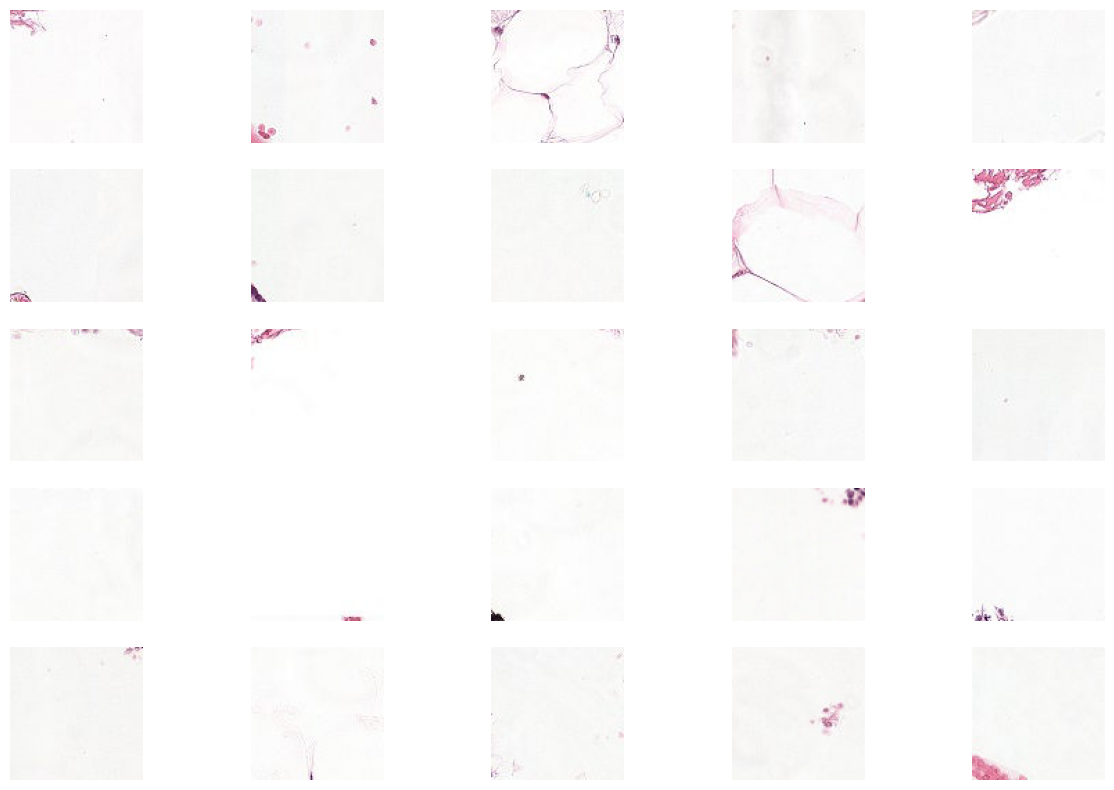

In [6]:
#calculate pixel intensity of every image and append it to a list
means = []
for img in train_imgs:
    img = os.path.join('data/train', img)
    arr = np.array(Image.open(img).convert('RGB'))
    means.append(arr.mean())

outlier_idxs = []
for i, j in enumerate(means):
    if j < 10 or j > 245:
        outlier_idxs.append(i)
outlier_imgs = []
for i in outlier_idxs:
    outlier_imgs.append(train_imgs[i])

#plot some of them as an example
fig, axes = plt.subplots(5, 5, figsize=(15, 10))
for ax, img_name in zip(axes.flatten(), outlier_imgs):
    path = os.path.join('data/train', img_name)
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
plt.show()

<hr>
Images with a normal amount of exposure are shown below.

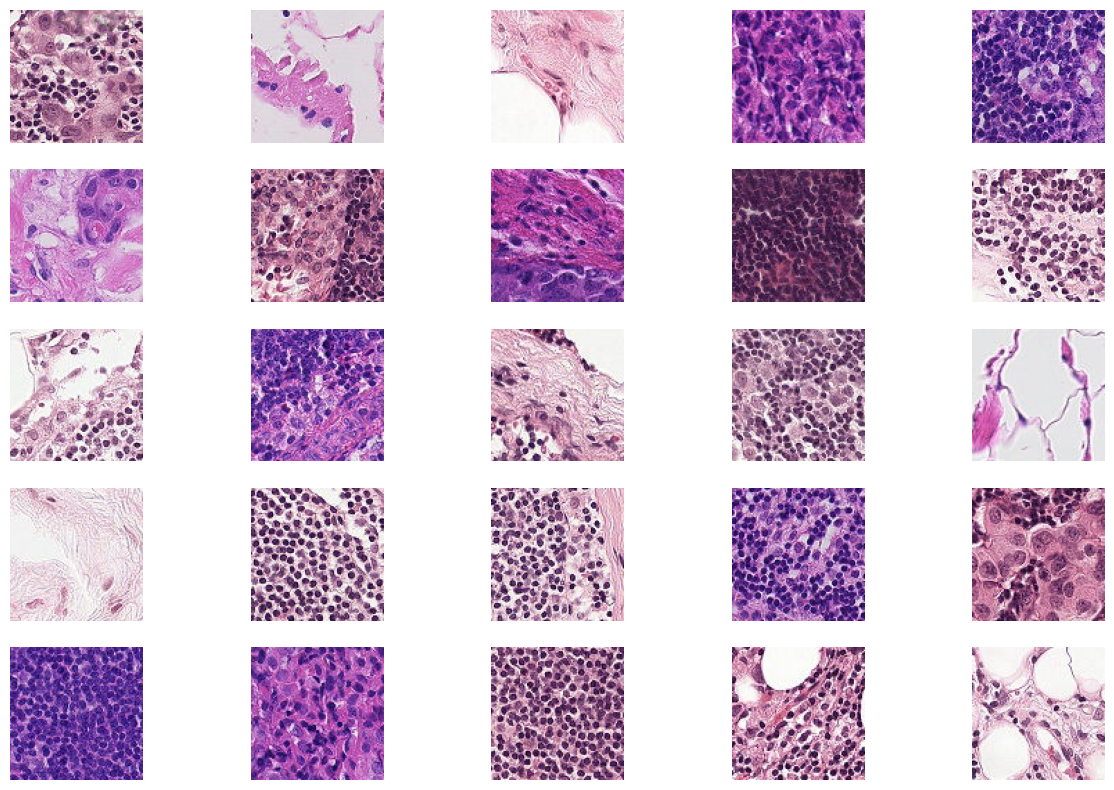

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(15, 10))
for ax, img_name in zip(axes.flatten(), train_imgs):
    path = os.path.join('data/train', img_name)
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
plt.show()

In [8]:
df_filtered = df[~df['id'].isin(outlier_imgs)].copy()
print(f"Dropped {len(df) - len(df_filtered)} overexposed samples")

Dropped 643 overexposed samples


### Flow From Dataframe
The keras utility `flow_from_dataframe` performs a lot of operations to make the images usable in a neural network. It's reading in the filenames from the `df` and the labels. It's then mapping these filenames to images in `data/train/*.tif`. It then loads the images as needed, batchwise (32 here). Each image is then resized to the `target_size`, and converted to a numpy array. This is done on the training images and the testing images. Obviously, the testing images do not have a label so that is not performed. Every pixel value is also rescaled from [0,255] to [0,1]. Networks train better when input values are in a small, normalized range such as this.

For the training set, the `flow_from_dataframe` will also split the data into a 80/20 train/validation split. This is done to check for overfitting when training the models.


In [9]:
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_set = datagen.flow_from_dataframe(
    dataframe = df_filtered,
    directory = 'data/train',
    x_col = 'id',
    y_col = 'label',
    target_size = (96,96),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = True,
    subset = 'training'
)
val_set = datagen.flow_from_dataframe(
    dataframe = df_filtered,
    directory = 'data/train',
    x_col = 'id',
    y_col = 'label',
    target_size = (96,96),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = True,
    subset = 'validation'
)
datagen = ImageDataGenerator(rescale=1./255)
train_set_T = datagen.flow_from_dataframe(
    dataframe = df_filtered,
    directory = 'data/train',
    x_col = 'id',
    y_col = 'label',
    target_size = (96,96),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = True,
)

Found 175506 validated image filenames belonging to 2 classes.
Found 43876 validated image filenames belonging to 2 classes.
Found 219382 validated image filenames belonging to 2 classes.


In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    directory = 'data/test',
    x_col = 'id',
    y_col = 'None',
    target_size = (96,96),
    batch_size = 32,
    class_mode = None,
    shuffle = False
)

Found 57458 validated image filenames.


### NN Model #1
<hr>

The model is created below using `Keras`. The model layers are:

`Input` -> `Convolution` -> `MaxPooling` -> `Convolution` -> `MaxPooling` -> `Convolution` -> `MaxPooling` -> `Flatten` -> `Dense` -> `Dropout` -> `Dense`

Each `Convolution` and `Dense` layers are using `relu` as their activation function. The output layer, `Dense`, is using a `sigmoid` function since this is a classification 0/1 problem.

Each `Convolution` layer is using a 3x3 filter. Each convolution layer gradually increases the number of filters (32 -> 64 -> 128). It can learn local patterns like edges, blobs, shapes, etc. Stacking up multiple convolution layers allows the neural network to build up from small patterns into recognizing complex patterns such as cluster of cancer cells, layer by layer.

`MaxPooling` layers are also used after each convolution layer. It takes the maximum value in each 2x2 block and then moves on. A 96 x 96 feature-map becomes 48x48. This lets the model reduce spatial dimensions, reduces computation, and makes feature detection robust to small movements.

`Flatten` layer collapses the spatial features into a single vector.

`Dense` layer combines all of the features. Each of the neurons in this layer computes a weighted sum of all the incoming features. This lets each unit focus on a combination of features. It turns the detectors into a compact nonlinear space where "cancerous" and "noncancerous" can be cleanly separated.

`Dropout` is added into the model to give the model some regularization. This randomly drops half off the `Dense` layer activations in each batch which will prevent the model from overfitting on any one feature too much. 

The network is using the 'adam' optimizer. This choice combines the advantages of SGD-Momentum and SGD-RMSProp into one algorithm. It does not require careful tuning of the global learning rate like an SGD algorithm and tends to work fine with the default parameters (learning rate = 0.001).

In [11]:
def make_model_1():
    model = Sequential()
    model.add(Input(shape=(96,96,3)))
    model.add(layers.Conv2D(32, (3,3),activation = 'relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [237]:
model = make_model_1()
model.compile(optimizer='adam',metrics=['accuracy'],loss='binary_crossentropy')

In [239]:
history_1 = model.fit(train_set,validation_data = val_set,epochs=30)

Epoch 1/30


/home/lukeunix/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5485/5485 ━━━━━━━━━━━━━━━━━━━━ 176s 32ms/step - accuracy: 0.7881 - loss: 0.4628 - val_accuracy: 0.8549 - val_loss: 0.3313
Epoch 2/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.8594 - loss: 0.3349 - val_accuracy: 0.8814 - val_loss: 0.2884
Epoch 3/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 92s 17ms/step - accuracy: 0.8820 - loss: 0.2882 - val_accuracy: 0.8987 - val_loss: 0.2549
Epoch 4/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.8957 - loss: 0.2586 - val_accuracy: 0.9040 - val_loss: 0.2416
Epoch 5/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.9033 - loss: 0.2409 - val_accuracy: 0.8934 - val_loss: 0.2795
Epoch 6/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.9119 - loss: 0.2242 - val_accuracy: 0.9105 - val_loss: 0.2315
Epoch 7/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.9174 - loss: 0.2108 - val_accuracy: 0.9129 - val_loss: 0.2240
Epoch 8/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.9236 - loss: 0.1

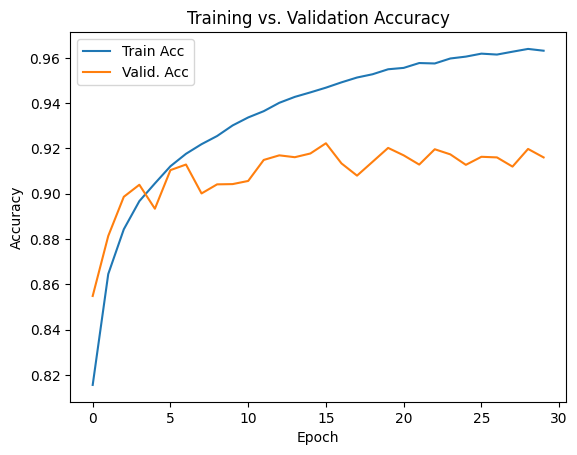

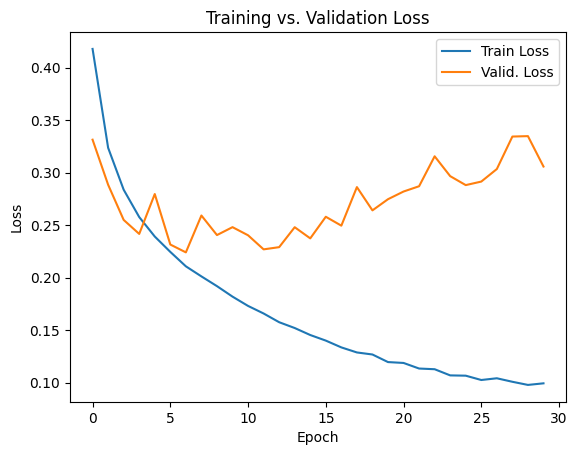

In [240]:
plt.plot(history_1.history['accuracy'],    label='Train Acc')
plt.plot(history_1.history['val_accuracy'], label='Valid. Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_1.history['loss'],    label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Valid. Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

<hr>
From the above graphs, it's clear that overfitting starts to occur at ~10 epochs and higher since the validation loss starts to increase after it initially dipped. Similarly in the accuracy chart, the validation accuracy hits a peak value and then plateaus. Another decent indicator that additional epochs are not adding any value and are causing overfitting.

Below, we will run the model up to 10 epochs and then predict the test set and see what the kaggle accuracy comes back as.

In [241]:
model.fit(train_set_T,epochs=10)
preds = model.predict(test_set)
pred_class = (preds > 0.5).astype(int)
test_df['pred_labels'] = pred_class

Epoch 1/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step - accuracy: 0.9507 - loss: 0.1420
Epoch 2/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 88s 13ms/step - accuracy: 0.9522 - loss: 0.1337
Epoch 3/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 86s 13ms/step - accuracy: 0.9537 - loss: 0.1278
Epoch 4/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.9555 - loss: 0.1223
Epoch 5/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.9564 - loss: 0.1183
Epoch 6/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 88s 13ms/step - accuracy: 0.9577 - loss: 0.1157
Epoch 7/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 92s 13ms/step - accuracy: 0.9578 - loss: 0.1129
Epoch 8/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.9578 - loss: 0.1157
Epoch 9/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.9606 - loss: 0.1077
Epoch 10/10
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step - accuracy: 0.9605 - loss: 0.1080
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step


In [242]:
ids = test_df['id'].str.replace('.tif','',regex=False)
pred_labels = test_df['pred_labels']
submit_df = pd.DataFrame({
    'id':ids,
    'label':pred_labels
})
submit_df.head
submit_df.to_csv('data/submission.csv', index=False)

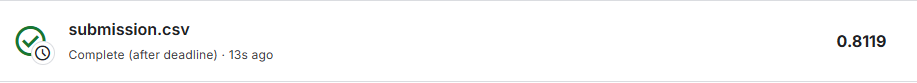

The result is shown above. About ~0.80 accuracy. Not bad.

### NN Model 1 - SGD Optimizer

Will perform a similar exercise as before. Run through 30 epochs and plot the accuracy/loss versus epochs. Will use an `SGD` optimizer this time and will tweak the learning rate values a few times to see how it changes the graphs. The same model structure as before will be used, with the exception of the optimizer.

Need to find a learning rate that is fast but not too fast and that reaches a minimum validation error.

### Learning rate 0.01

In [243]:
model = make_model_1()
opt = SGD(learning_rate=.01,momentum=0.9,nesterov=True)
model.compile(optimizer=opt,metrics=['accuracy'],loss='binary_crossentropy')

In [244]:
history_2 = model.fit(train_set,validation_data = val_set,epochs=30)

Epoch 1/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - accuracy: 0.7728 - loss: 0.4811 - val_accuracy: 0.8626 - val_loss: 0.3256
Epoch 2/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 90s 16ms/step - accuracy: 0.8646 - loss: 0.3225 - val_accuracy: 0.8888 - val_loss: 0.2664
Epoch 3/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 92s 17ms/step - accuracy: 0.8908 - loss: 0.2672 - val_accuracy: 0.8986 - val_loss: 0.2514
Epoch 4/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.9055 - loss: 0.2351 - val_accuracy: 0.9068 - val_loss: 0.2333
Epoch 5/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.9164 - loss: 0.2090 - val_accuracy: 0.9081 - val_loss: 0.2351
Epoch 6/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.9280 - loss: 0.1843 - val_accuracy: 0.9131 - val_loss: 0.2212
Epoch 7/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.9376 - loss: 0.1625 - val_accuracy: 0.9162 - val_loss: 0.2304
Epoch 8/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.9445 -

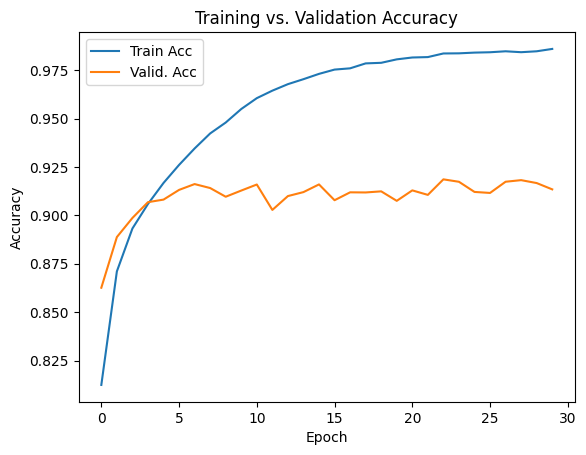

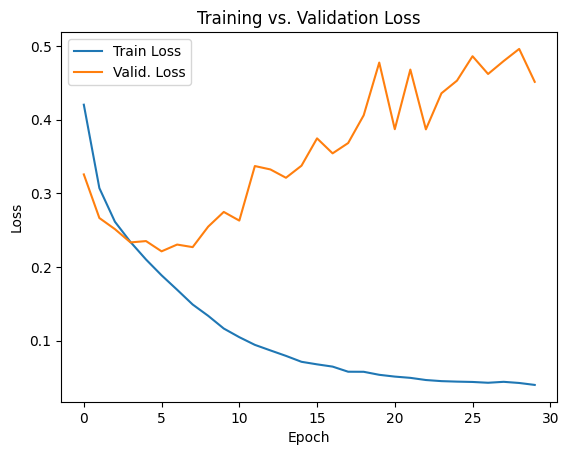

In [245]:
plt.plot(history_2.history['accuracy'],    label='Train Acc')
plt.plot(history_2.history['val_accuracy'], label='Valid. Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_2.history['loss'],    label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Valid. Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

A learning rate of 0.01 seems reasonable and is quick. The model reaches the best fit at ~5 epochs and the loss is in the low 0.2's.

<hr>

### Learning Rate 0.001

In [246]:
model = make_model_1()
opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
model.compile(optimizer=opt,metrics=['accuracy'],loss='binary_crossentropy')

In [247]:
history_3 = model.fit(train_set,validation_data = val_set,epochs=30)

Epoch 1/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 16ms/step - accuracy: 0.7429 - loss: 0.5203 - val_accuracy: 0.8178 - val_loss: 0.4074
Epoch 2/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.8286 - loss: 0.3957 - val_accuracy: 0.8492 - val_loss: 0.3560
Epoch 3/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 86s 16ms/step - accuracy: 0.8435 - loss: 0.3651 - val_accuracy: 0.8591 - val_loss: 0.3301
Epoch 4/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.8538 - loss: 0.3448 - val_accuracy: 0.8641 - val_loss: 0.3231
Epoch 5/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.8598 - loss: 0.3295 - val_accuracy: 0.8721 - val_loss: 0.3066
Epoch 6/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.8680 - loss: 0.3122 - val_accuracy: 0.8734 - val_loss: 0.2959
Epoch 7/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.8753 - loss: 0.3012 - val_accuracy: 0.8847 - val_loss: 0.2780
Epoch 8/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.8822 -

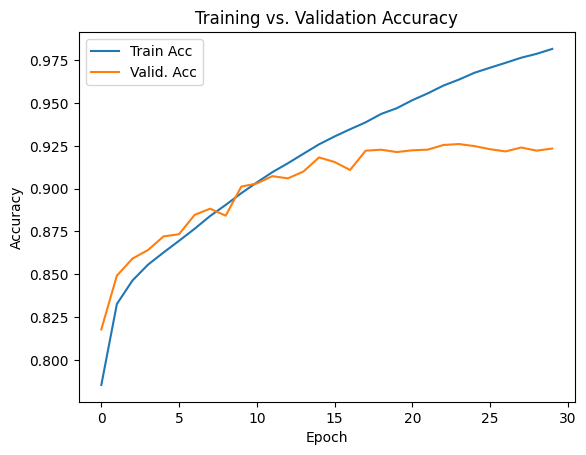

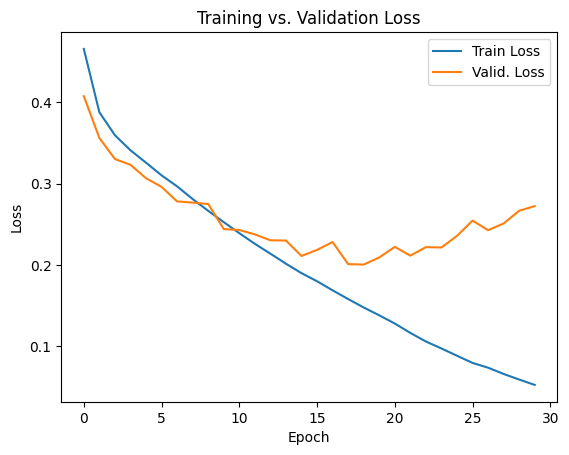

In [258]:
plt.plot(history_3.history['accuracy'],    label='Train Acc')
plt.plot(history_3.history['val_accuracy'], label='Valid. Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_3.history['loss'],    label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Valid. Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

A learning rate of 0.001 is obviously slower than 0.01. The model reaches the best fit at ~18 epochs and the loss is in the low 0.2's. 

<hr>

### Learning Rate 0.0001

In [249]:
model = make_model_1()
opt = SGD(learning_rate=.0001,momentum=0.9,nesterov=True)
model.compile(optimizer=opt,metrics=['accuracy'],loss='binary_crossentropy')

In [250]:
history_4 = model.fit(train_set,validation_data = val_set,epochs=30)

Epoch 1/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 96s 17ms/step - accuracy: 0.6235 - loss: 0.6431 - val_accuracy: 0.7794 - val_loss: 0.4904
Epoch 2/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.7766 - loss: 0.4935 - val_accuracy: 0.7897 - val_loss: 0.4642
Epoch 3/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.7895 - loss: 0.4661 - val_accuracy: 0.7995 - val_loss: 0.4494
Epoch 4/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 92s 17ms/step - accuracy: 0.7992 - loss: 0.4503 - val_accuracy: 0.8109 - val_loss: 0.4256
Epoch 5/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 90s 16ms/step - accuracy: 0.8073 - loss: 0.4348 - val_accuracy: 0.8170 - val_loss: 0.4170
Epoch 6/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 92s 17ms/step - accuracy: 0.8153 - loss: 0.4214 - val_accuracy: 0.8125 - val_loss: 0.4191
Epoch 7/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 90s 16ms/step - accuracy: 0.8235 - loss: 0.4079 - val_accuracy: 0.8303 - val_loss: 0.3904
Epoch 8/30
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 91s 17ms/step - accuracy: 0.8273 -

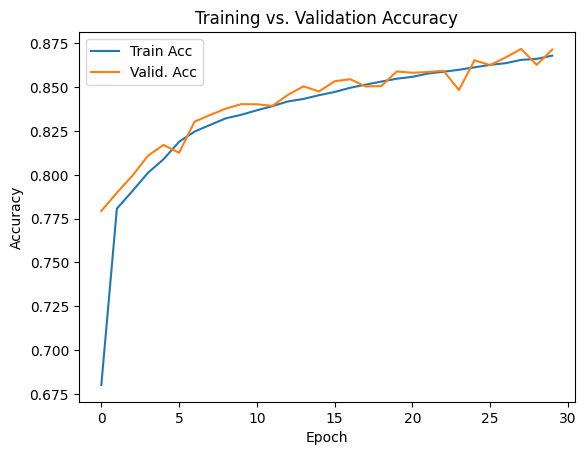

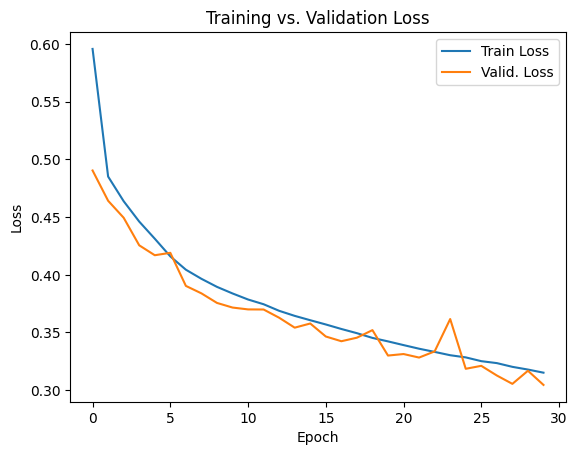

In [259]:
plt.plot(history_4.history['accuracy'],    label='Train Acc')
plt.plot(history_4.history['val_accuracy'], label='Valid. Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_4.history['loss'],    label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Valid. Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

A learning rate of 0.0001 is **very** slow. The validation error is still dropping even after 30 epochs. 

<hr>

With a learning rate of 0.01 found, the model will be re-trained on the total training data up to epoch 5. Predictions on the test data will be calculated and then graded by Kaggle.

In [12]:
model = make_model_1()
opt = SGD(learning_rate=.01,momentum=0.9,nesterov=True)
model.compile(optimizer=opt,metrics=['accuracy'],loss='binary_crossentropy')

I0000 00:00:1746116684.493546     516 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6073 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [13]:
history_5 = model.fit(train_set_T,epochs=6)
preds = model.predict(test_set)
pred_class = (preds > 0.5).astype(int)
test_df['pred_labels'] = pred_class

Epoch 1/6


/home/lukeunix/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746116687.706239     843 service.cc:152] XLA service 0x7fbc64004bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746116687.706263     843 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5
I0000 00:00:1746116687.858859     843 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/6856 ━━━━━━━━━━━━━━━━━━━━ 3:42:19 2s/step - accuracy: 0.4688 - loss: 0.6956

I0000 00:00:1746116688.802799     843 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6856/6856 ━━━━━━━━━━━━━━━━━━━━ 93s 13ms/step - accuracy: 0.7715 - loss: 0.4770
Epoch 2/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 88s 13ms/step - accuracy: 0.8630 - loss: 0.3221
Epoch 3/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - accuracy: 0.8893 - loss: 0.2700
Epoch 4/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - accuracy: 0.9059 - loss: 0.2347
Epoch 5/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 88s 13ms/step - accuracy: 0.9164 - loss: 0.2094
Epoch 6/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step - accuracy: 0.9286 - loss: 0.1826
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step


In [14]:
ids = test_df['id'].str.replace('.tif','',regex=False)
pred_labels = test_df['pred_labels']
submit_df = pd.DataFrame({
    'id':ids,
    'label':pred_labels
})
submit_df.head
submit_df.to_csv('data/submission.csv', index=False)

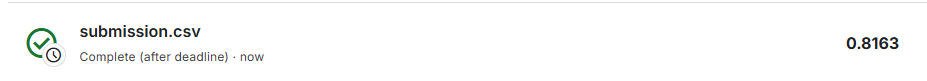

The result is shown above. About ~0.82 accuracy. Not bad.
<hr>

### NN - Crop Alt
The below model will crop out any sections of the image except for the center 32x32 section and see if this gives better results than using the entire image.

In [35]:
def make_model_2():
    model2 = Sequential()
    model2.add(Input(shape=(96,96,3)))
    model2.add(CenterCrop(32,32))
    model2.add(layers.Conv2D(32, (3,3),activation = 'relu'))
    model2.add(layers.BatchNormalization())
    model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model2.add(layers.MaxPooling2D((2, 2)))
    model2.add(layers.BatchNormalization())
    model2.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model2.add(layers.MaxPooling2D((2, 2)))
    model2.add(layers.BatchNormalization())
    model2.add(layers.Flatten())
    model2.add(layers.Dense(128, activation='relu'))
    model2.add(layers.Dropout(0.5))
    model2.add(layers.Dense(1, activation='sigmoid'))
    return model2

In [20]:
model = make_model_2()
model.compile(optimizer='adam',metrics=['accuracy'],loss='binary_crossentropy')

In [22]:
model.fit(train_set,epochs=10)

Epoch 1/10


/home/lukeunix/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5485/5485 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - accuracy: 0.7588 - loss: 0.6058
Epoch 2/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 72s 13ms/step - accuracy: 0.8091 - loss: 0.4384
Epoch 3/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 72s 13ms/step - accuracy: 0.8291 - loss: 0.4006
Epoch 4/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 73s 13ms/step - accuracy: 0.8356 - loss: 0.3829
Epoch 5/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 72s 13ms/step - accuracy: 0.8414 - loss: 0.3694
Epoch 6/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.8485 - loss: 0.3562
Epoch 7/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.8540 - loss: 0.3436
Epoch 8/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.8596 - loss: 0.3303
Epoch 9/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 72s 13ms/step - accuracy: 0.8673 - loss: 0.3137
Epoch 10/10
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 73s 13ms/step - accuracy: 0.8704 - loss: 0.3033


In [23]:
preds = model.predict(test_set)
pred_class = (preds > 0.5).astype(int)
test_df['pred_labels'] = pred_class

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step


In [24]:
ids = test_df['id'].str.replace('.tif','',regex=False)
pred_labels = test_df['pred_labels']
submit_df = pd.DataFrame({
    'id':ids,
    'label':pred_labels
})
submit_df.head
submit_df.to_csv('data/submission.csv', index=False)

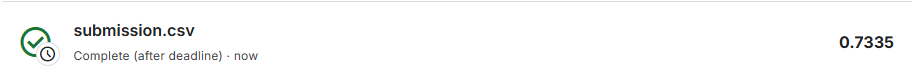

The results are not so good. It's apparent that there is useful information outside of the center 32 x 32 pixel region of each image.

### NN - VGGNet
I will attempt a different architecture, something similar to VGGNet.

`Input` -> `Conv` -> `Conv` -> `MaxPool` -> `Conv` -> `Conv` -> `MaxPool` -> `Conv` -> `MaxPool` -> `Flatten` -> `Dense` -> `Dropout` -> `Dense`

This architecture has additional convolution layers when compared to the previous architectures. This may help the network's ability to learn features.

In [27]:
def make_model_3():
    model3 = Sequential()
    model3.add(Input(shape=(96,96,3)))
    model3.add(layers.Conv2D(64, 3, padding='same', activation = 'relu'))
    model3.add(layers.Conv2D(64, 3, padding='same', activation = 'relu'))
    model3.add(layers.MaxPooling2D())
    model3.add(layers.Conv2D(128, 3, padding='same', activation = 'relu'))
    model3.add(layers.Conv2D(128, 3, padding='same', activation = 'relu'))
    model3.add(layers.MaxPooling2D())
    model3.add(layers.Conv2D(256, 3, padding='same', activation = 'relu'))
    model3.add(layers.MaxPooling2D())
    model3.add(layers.Flatten())
    model3.add(layers.Dense(256, activation='relu'))
    model3.add(layers.Dropout(0.5))
    model3.add(layers.Dense(1, activation='sigmoid'))
    return model3

In [28]:
model = make_model_3()
model.compile(optimizer='adam',metrics=['accuracy'],loss='binary_crossentropy')

In [29]:
history_6 = model.fit(train_set,validation_data = val_set,epochs=20)

Epoch 1/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 415s 75ms/step - accuracy: 0.7698 - loss: 0.4795 - val_accuracy: 0.8760 - val_loss: 0.2971
Epoch 2/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 429s 78ms/step - accuracy: 0.8798 - loss: 0.2932 - val_accuracy: 0.9091 - val_loss: 0.2332
Epoch 3/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 425s 77ms/step - accuracy: 0.9080 - loss: 0.2363 - val_accuracy: 0.9089 - val_loss: 0.2269
Epoch 4/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 427s 78ms/step - accuracy: 0.9208 - loss: 0.2077 - val_accuracy: 0.9260 - val_loss: 0.1997
Epoch 5/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 432s 79ms/step - accuracy: 0.9296 - loss: 0.1874 - val_accuracy: 0.9341 - val_loss: 0.1785
Epoch 6/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 413s 75ms/step - accuracy: 0.9368 - loss: 0.1710 - val_accuracy: 0.9367 - val_loss: 0.1730
Epoch 7/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 418s 76ms/step - accuracy: 0.9412 - loss: 0.1616 - val_accuracy: 0.9249 - val_loss: 0.1967
Epoch 8/20
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 429s 78ms/step - accuracy: 

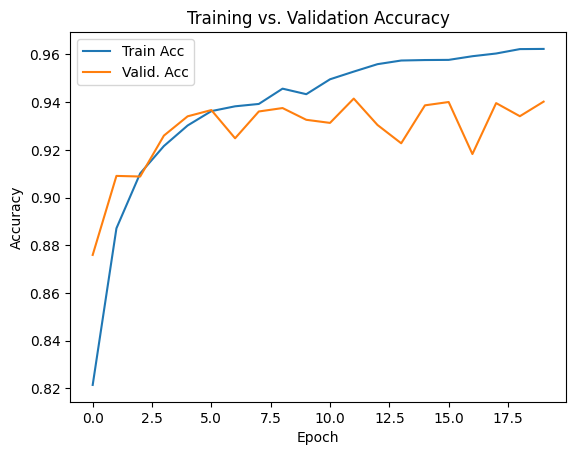

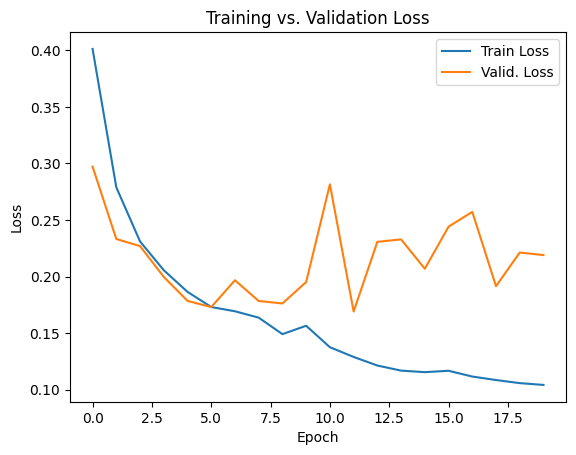

In [31]:
plt.plot(history_6.history['accuracy'],    label='Train Acc')
plt.plot(history_6.history['val_accuracy'], label='Valid. Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_6.history['loss'],    label='Train Loss')
plt.plot(history_6.history['val_loss'], label='Valid. Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

<hr>
The validation error bottoms out at around ~5 epochs, will use that to train the dataset and then to make predictions.

In [32]:
model = make_model_3()
model.compile(optimizer='adam',metrics=['accuracy'],loss='binary_crossentropy')

In [33]:
history_6 = model.fit(train_set_T,epochs=6)
preds = model.predict(test_set)
pred_class = (preds > 0.5).astype(int)
test_df['pred_labels'] = pred_class

Epoch 1/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 454s 66ms/step - accuracy: 0.7858 - loss: 0.4541
Epoch 2/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 453s 66ms/step - accuracy: 0.8954 - loss: 0.2620
Epoch 3/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 462s 67ms/step - accuracy: 0.9182 - loss: 0.2150
Epoch 4/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 457s 67ms/step - accuracy: 0.9296 - loss: 0.1897
Epoch 5/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 488s 71ms/step - accuracy: 0.9266 - loss: 0.1958
Epoch 6/6
6856/6856 ━━━━━━━━━━━━━━━━━━━━ 492s 72ms/step - accuracy: 0.9412 - loss: 0.1600
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step


In [34]:
ids = test_df['id'].str.replace('.tif','',regex=False)
pred_labels = test_df['pred_labels']
submit_df = pd.DataFrame({
    'id':ids,
    'label':pred_labels
})
submit_df.head
submit_df.to_csv('data/submission.csv', index=False)

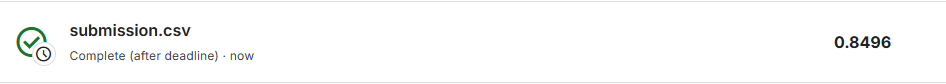

The result is shown above. This is the best result.

<hr>

## Results
|Model|Accuracy|
|-|-|
|Model 1 w/ Adam|0.81|
|Model 1 w/ SGD|0.82|
|Model 1 w/ Adam, Cropped Image| 0.73|
|VGGNet Model w/ Adam|0.85|

The Model 1 using the `Adam` optimizer did not require hyperparameter tuning. This is an optimizer that is usually very good "out of the box", and the results bear this out.

Model 1 using stochastic gradient descent (`SGD`) required some hyperparameter tuning to get a learning rate that was fast but not so fast it could not reach a minimum error value. 0.01 was a good value for the learning rate. 0.001 and 0.0001 were needlessly slow.

An attempt at training a model against a cropped version of the image was also attempted. The Kaggle instructions state "a positive label indicates that the center 32 x 32 pixel region of a patch contains at least one pixel of tumor tissue". I interpreted this to mean that this is where the anamolous tumor would always appear in each 96 x 96 image, but maybe I was wrong. The accuracy was lower for this model.

The VGGNet model was very similar to the Model 1 except it has additional convolution layers. It seems that these additional layers made a significant difference since the accuracy jumped from 0.81 -> 0.85. The drawback is additional computation time. Each epoch takes ~450 seconds, whereas the simpler model takes ~90 seconds per epoch. 

## Conclusions

A lot of the work in this project was modelling a neural network with excess epochs and then deciding where the true stopping point is (where the validation error is at a minimum) and then re-modelling to that epoch number. This is not entirely necessary since `Keras` supports an early_callback function that can automatically stop calculating epochs once the loss stops decreasing by a tolerable amount. For projects where it is not important to show the thought process like this one, I will probably make use of this functionality.

Figuring out how to enable tensorflow to use my GPU is essential. Before I worked through that, even the basic model was taking 450 seconds per epoch calculation. The deeper VGGnet would be much worse. It might be necessary to use cloud GPU's in the future for more intense projects since it could become unfeasible if the time to train the network is too large.

`Adam` is a good optimizer but there is still a benefit to using a tuned `SGD` optimizer. Finely tuned parameters should overfit less than `Adam` will. It might be a good practice to get a quick idea of how good your model is with `Adam` and then work on fine-tuning the `SGD` parameters.

### References
https://www.kaggle.com/competitions/histopathologic-cancer-detection/data